전처리 과정 생략
자치구 별 단계 구분도 시각화

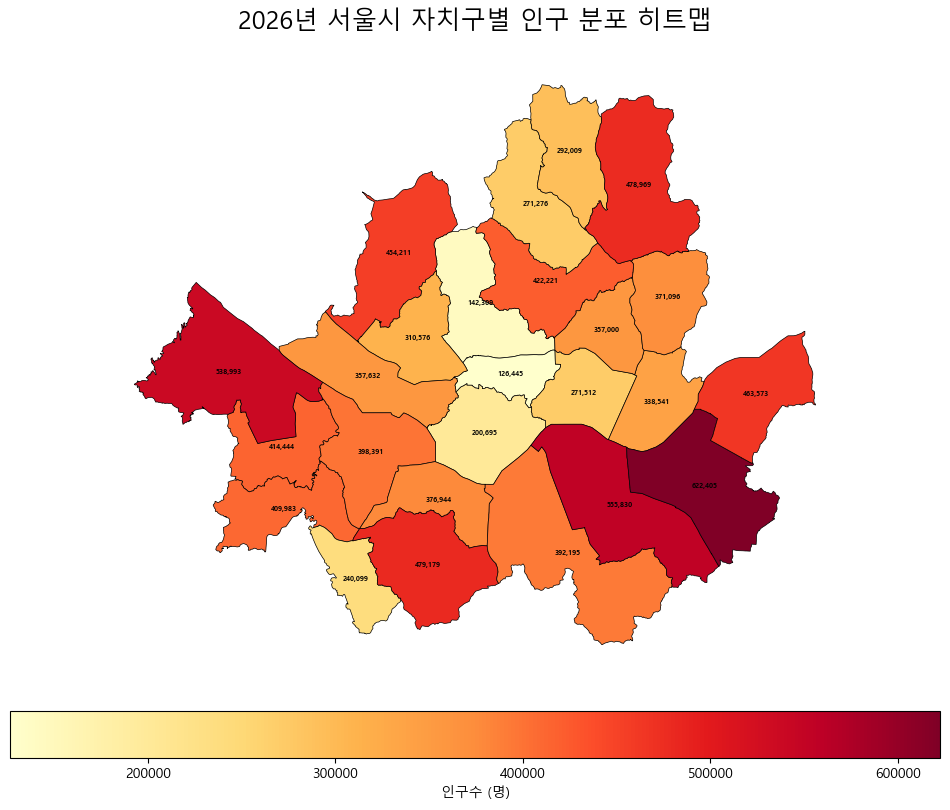

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from plt_style import set_korean

set_korean()

# --- 1. 데이터 로드 및 전처리 ---
# CSV 파일 읽기 (헤더가 복잡하므로 header=None으로 읽은 뒤 필요한 행/열만 추출)
df = pd.read_csv('data/자치구별+총인구(추계인구).csv', header=None)

# 데이터 추출 규칙:
# - 행: 인덱스 4번부터 실제 자치구 데이터 시작 (3번 '합계' 행 제외)
# - 열: 인덱스 1번(자치구명), 인덱스 2번(총인구 소계)
pop_df = df.iloc[4:, [1, 2]].copy()
pop_df.columns = ['자치구', '인구수']

# '인구수' 컬럼을 숫자로 변환
pop_df['인구수'] = pd.to_numeric(pop_df['인구수'])

# --- 2. 지리 정보(GeoJSON) 로드 ---
# 사용자가 지정한 경로의 파일 로드
gdf = gpd.read_file('polygon/서울시_자치구.geojson')
merge_col = 'SIG_KOR_NM' 

# --- 3. 데이터 병합 (Join) ---
merged = gdf.merge(pop_df, left_on=merge_col, right_on='자치구')

# --- 4. 정적 단계 구분도(Choropleth Map) 시각화 ---
# 한글 깨짐 방지 설정 (로컬 환경의 폰트에 맞춰 설정하세요)
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 기준
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 1) 지도 그리기
merged.plot(column='인구수', 
            cmap='YlOrRd',       # 노랑-주황-빨강 색상 조합
            legend=True, 
            edgecolor='black',    # 구 경계선 색상
            linewidth=0.5,        # 경계선 두께
            ax=ax,
            legend_kwds={'label': "인구수 (명)", 'orientation': "horizontal", 'pad': 0.05})

# 2) 각 자치구 위에 숫자(인구수) 추가하기
for idx, row in merged.iterrows():
    # 폴리곤의 중심점 구하기
    centroid = row.geometry.centroid
    
    # 숫자 포맷팅 (예: 142,309명 -> 천단위 콤마 추가)
    label = f"{int(row['인구수']):,}"
    
    # 텍스트 출력 (중심점 x, y 좌표 사용)
    ax.text(centroid.x, centroid.y, label, 
            fontsize=5, 
            ha='center',      # 가로 정렬: 중앙
            va='center',      # 세로 정렬: 중앙
            fontweight='bold', 
            color='black')    # 배경색에 따라 'white'로 변경 가능

# 제목 및 축 설정
plt.title('2026년 서울시 자치구별 인구 분포 히트맵', fontsize=18, pad=20)
ax.axis('off') # 위도/경도 축 숨기기

# 이미지 저장 또는 출력
plt.savefig('output/자치구 별 인구 분포.png', dpi=300, bbox_inches='tight')
plt.show()